# Freight Rate: Exploratory Data Analysis

What the data says, and what each finding forces the model to do.

Every conclusion here is reproduced by the pipeline in `src/freight_rate/`. This notebook
reads from those modules rather than reimplementing them, so nothing can drift between
what is shown here and what actually runs.

**Contents**

1. [The shape of the problem](#1): a forward-in-time holdout, not a random one
2. [The target](#2): a long right tail
3. [`quote_signal`](#3): the finding that reframes the task
4. [Data quality](#4): sign errors and gaps
5. [`market_index`](#5): a daily series wearing a per-load disguise
6. [Distribution shift](#6): the market moves between train and validation
7. [Cold start](#7): eight cities that appear only at prediction time
8. [Equipment](#8): the quote does not price it
9. [Temporal structure](#9): autocorrelation and a weekly cycle
10. [What this implies](#10)

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Read from the pipeline package so this notebook cannot drift from what runs.
# `pip install -e .` makes it importable from anywhere, so no sys.path juggling.
from freight_rate import cleaning, loading, market

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E3E9EA",
    "grid.linewidth": 0.8,
    "font.size": 10,
})
TEAL, RUST, AMBER, SLATE = "#064A56", "#B3261E", "#B26A00", "#607478"

train_raw = loading.load_train()
valid_raw = loading.load_validation()
train = cleaning.clean(train_raw)
valid = cleaning.clean(valid_raw)

train["rpm"] = train.posted_rate / train.distance
print(f"train      {train.shape}   {train.date.min():%Y-%m-%d} to {train.date.max():%Y-%m-%d}")
print(f"validation {valid.shape}   {valid.date.min():%Y-%m-%d} to {valid.date.max():%Y-%m-%d}")

train      (48000, 15)   2025-01-01 to 2025-10-31
validation (12000, 13)   2025-11-01 to 2025-12-31


<a id="1"></a>
## 1. The shape of the problem

Training stops on 31 October; prediction starts on 1 November. The holdout is strictly
forward in time, which is the single most important structural fact about this task:
it rules out random cross-validation before any modelling decision is made.

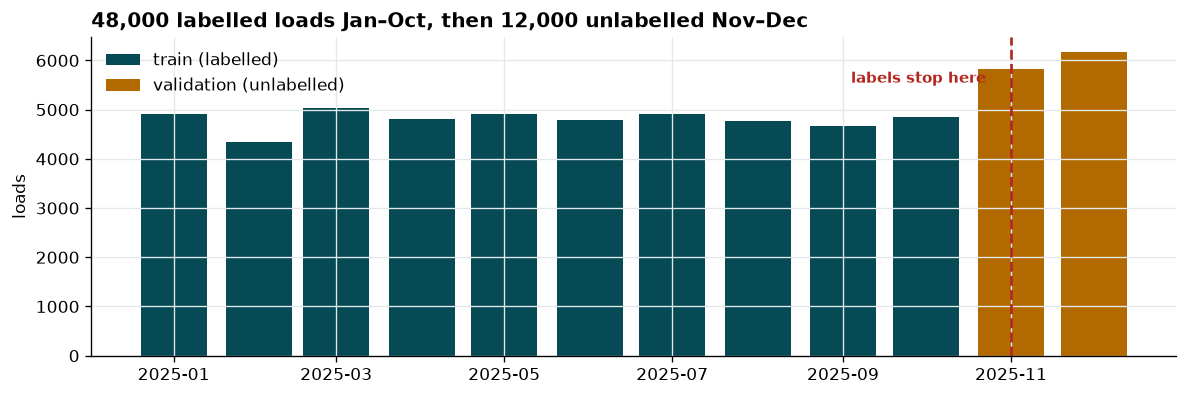

In [2]:
fig, ax = plt.subplots(figsize=(10, 3.4))
counts = pd.concat([
    train.assign(split="train"),
    valid.assign(split="validation"),
]).groupby([pd.Grouper(key="date", freq="MS"), "split"]).size().unstack(fill_value=0)

ax.bar(counts.index, counts.get("train", 0), width=24, color=TEAL, label="train (labelled)")
ax.bar(counts.index, counts.get("validation", 0), width=24, color=AMBER, label="validation (unlabelled)")
ax.axvline(pd.Timestamp("2025-11-01"), color=RUST, linestyle="--", linewidth=1.6)
ax.annotate("labels stop here", xy=(pd.Timestamp("2025-11-01"), counts.values.max() * 0.9),
            xytext=(-96, 0), textcoords="offset points", color=RUST, fontweight="bold", fontsize=9)
ax.set_ylabel("loads")
ax.set_title("48,000 labelled loads Jan–Oct, then 12,000 unlabelled Nov–Dec", loc="left", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

<a id="2"></a>
## 2. The target

`posted_rate` is the total dollars paid for a load, so it scales with trip length, and
its correlation with `distance` is 0.91. Dividing it out gives rate-per-mile, which is the
quantity actually worth modelling. Its tail is long: a median of \$2.15/mile, but the
top 0.7% of loads run past \$4 and reach \$14.

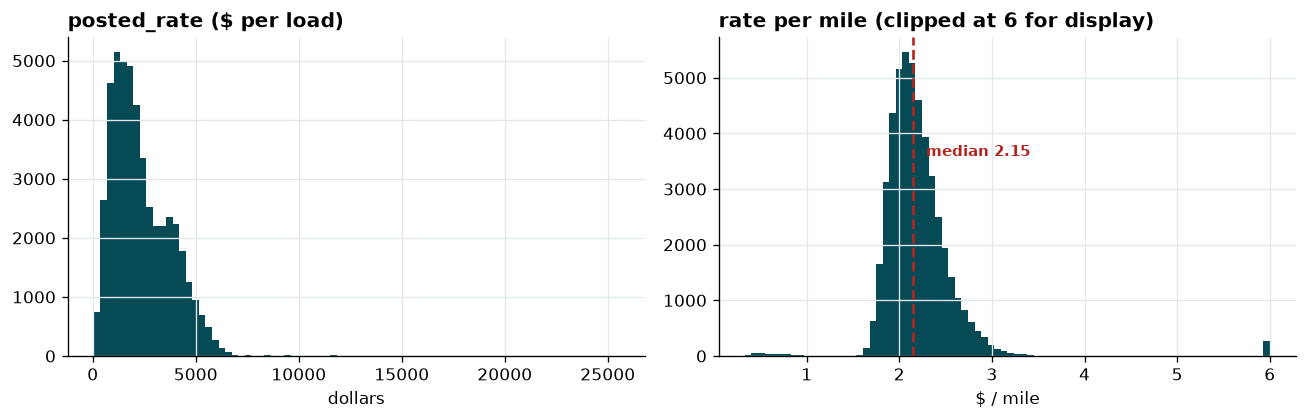

correlation, distance vs posted_rate : 0.909
share of loads above $4/mile         : 0.71%
max rate per mile                    : $14.13


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(train.posted_rate, bins=80, color=TEAL)
axes[0].set_title("posted_rate ($ per load)", loc="left", fontweight="bold")
axes[0].set_xlabel("dollars")

axes[1].hist(train.rpm.clip(upper=6), bins=80, color=TEAL)
axes[1].axvline(train.rpm.median(), color=RUST, linestyle="--", linewidth=1.6)
axes[1].annotate(f"median {train.rpm.median():.2f}", xy=(train.rpm.median(), 0),
                 xytext=(8, 120), textcoords="offset points", color=RUST, fontweight="bold", fontsize=9)
axes[1].set_title("rate per mile (clipped at 6 for display)", loc="left", fontweight="bold")
axes[1].set_xlabel("$ / mile")
plt.tight_layout()
plt.show()

print(f"correlation, distance vs posted_rate : {train.distance.corr(train.posted_rate):.3f}")
print(f"share of loads above $4/mile         : {(train.rpm > 4).mean():.2%}")
print(f"max rate per mile                    : ${train.rpm.max():.2f}")

<a id="3"></a>
## 3. `quote_signal`: the finding that reframes the task

A correlation matrix says `quote_signal` is worthless: its correlation with
`posted_rate` is **−0.04**. That is misleading. The column is a dollars-per-mile quote,
so it acts *multiplicatively* with distance, and the heavy tail crushes the linear
correlation.

Multiply it out and the picture inverts.

In [4]:
baseline = train.distance * train.quote_signal
ratio = train.posted_rate / baseline
ape = (baseline - train.posted_rate).abs() / train.posted_rate * 100

print(f"correlation, quote_signal vs posted_rate : {train.quote_signal.corr(train.posted_rate):+.3f}   <- looks useless")
print()
print("but  predicted = distance x quote_signal, with no model at all:")
print(f"    within  2% of the actual rate : {(ratio.sub(1).abs() <= 0.02).mean():.1%} of loads")
print(f"    within 10% of the actual rate : {(ratio.sub(1).abs() <= 0.10).mean():.1%} of loads")
error = (baseline - train.posted_rate).abs()
print(f"    median absolute % error        : {ape.median():>8.2f}%")
print(f"    mean absolute % error  (MAPE)  : {ape.mean():>8.2f}%")
print(f"    median absolute error          : ${error.median():>8,.2f}")
print(f"    mean absolute error    (MAE)   : ${error.mean():>8,.2f}")

correlation, quote_signal vs posted_rate : -0.040   <- looks useless

but  predicted = distance x quote_signal, with no model at all:
    within  2% of the actual rate : 49.9% of loads
    within 10% of the actual rate : 66.9% of loads
    median absolute % error        :     2.02%
    mean absolute % error  (MAPE)  :    11.37%
    median absolute error          : $   55.55
    mean absolute error    (MAE)   : $  232.26


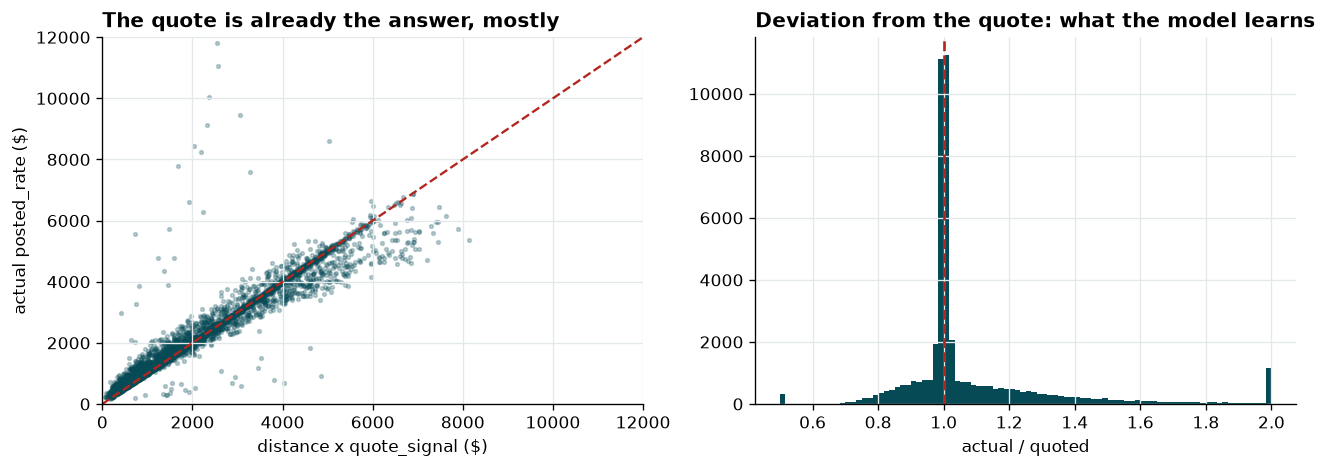

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

sample = train.sample(4000, random_state=0)
axes[0].scatter(sample.distance * sample.quote_signal, sample.posted_rate,
                s=5, alpha=0.25, color=TEAL)
limit = 12000
axes[0].plot([0, limit], [0, limit], color=RUST, linewidth=1.4, linestyle="--")
axes[0].set_xlim(0, limit); axes[0].set_ylim(0, limit)
axes[0].set_xlabel("distance x quote_signal ($)")
axes[0].set_ylabel("actual posted_rate ($)")
axes[0].set_title("The quote is already the answer, mostly", loc="left", fontweight="bold")

axes[1].hist(ratio.clip(0.5, 2.0), bins=90, color=TEAL)
axes[1].axvline(1.0, color=RUST, linestyle="--", linewidth=1.6)
axes[1].set_xlabel("actual / quoted")
axes[1].set_title("Deviation from the quote: what the model learns", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

Loads scatter on *both* sides of the line (57.8% above, 42.2% below), so the quote is a
central estimate, not a floor. What is lopsided is how far each side reaches: the 1st
percentile sits 27% below the quote, the 99th sits 155% above, and the extreme runs to
11.4×. Skew is **6.64**.

That is why the model predicts `log(posted_rate / (distance × quote_signal))` rather
than the rate itself. The **ratio** means it only has to learn the deviation from a
quote that is already within 2% half the time. The **log** does two things: it makes a
doubling and a halving equally wrong (±0.69, rather than +1.00 against −0.50), and it
stops the worst load steering the fit: under squared error that load outweighs a
typical one by 10,757× on the raw ratio but only 651× in log space. Skew falls from
6.64 to 0.96.

<a id="4"></a>
## 4. Data quality

Three issues, all in the load-attribute columns rather than the target.

In [6]:
issues = pd.DataFrame([
    {"issue": "negative weight",
     "train": int((train_raw.weight < 0).sum()), "validation": int((valid_raw.weight < 0).sum()),
     "handling": "sign error - abs(), no flag"},
    {"issue": "missing weight",
     "train": int(train_raw.weight.isna().sum()), "validation": int(valid_raw.weight.isna().sum()),
     "handling": "imputed in RateModel.fit from TRAIN medians"},
    {"issue": "missing market_index",
     "train": int(train_raw.market_index.isna().sum()), "validation": int(valid_raw.market_index.isna().sum()),
     "handling": "filled from the same date's mean"},
])
display(issues)

# Negative weights are sign errors, not corrupt records: their magnitudes match the rest.
negative = train_raw.loc[train_raw.weight < 0, "weight"].abs()
positive = train_raw.loc[train_raw.weight > 0, "weight"]
print(f"median |weight| among negatives : {negative.median():,.0f}")
print(f"median  weight  among positives : {positive.median():,.0f}")
print("-> same distribution, so the magnitude is trustworthy and only the sign is wrong")

,issue,train,validation,handling
0,negative weight,292,145,"sign error - abs(), no flag"
1,missing weight,300,165,imputed in RateModel.fit from TRAIN medians
2,missing market_index,374,249,filled from the same date's mean


median |weight| among negatives : 31,822
median  weight  among positives : 31,494
-> same distribution, so the magnitude is trustworthy and only the sign is wrong


**Where each repair happens, and why it matters.** The two `weight` issues and the
`market_index` gaps are fixed in different places, on purpose.

`market_index` is filled during cleaning, from the mean of its own date. Section 5 below
shows why that is a recovery rather than a guess: 97.8% of the column's variance is
explained by date alone. A row's own date is available at prediction time, so nothing
about the future is used.

**`weight` is different.** `RandomForestRegressor` cannot accept a missing value, so the
300 training and 165 validation blanks must be filled with something. The fill value is
the median weight, 31,496 lb, and it is computed **only from the January–October rows**,
then reused unchanged on November and December.

That placement is the whole point. Imputing during cleaning would take the median across
all 60,000 rows, which lets the November–December loads help set the number used to fill
their own blanks. The gap is small here (31,496 lb against 31,467 lb pooled, a difference
of 29 lb) but the habit is what generalises: a fill value is a *fitted parameter*, so it
belongs in `fit`, learned from training data alone.

So imputation lives in `RateModel.fit`, which stores it, and `RateModel.predict` only
reads it back. `predict` never computes a median, which means it cannot peek even by
accident.

Filling with a median is safe here because the rows missing a weight are not otherwise
unusual: they price like the rest (median rate/mile 2.1176 against 2.1456, Mann-Whitney
p = 0.234) and carry the same equipment mix.

<a id="5"></a>
## 5. `market_index`: a daily series wearing a per-load disguise

On a day with ~157 loads there are ~155 distinct `market_index` values, which looks
like a per-load attribute. It is not. Decomposing the variance shows the date explains
almost all of it.

In [7]:
daily = train.groupby("date").market_index.transform("mean")
grand = train.market_index.mean()
explained = ((daily - grand) ** 2).sum() / ((train.market_index - grand) ** 2).sum()

print(f"variance explained by date alone : {explained:.1%}")
print(f"left over as within-day scatter  : {1 - explained:.1%}")
print()
print(f"std of the daily means  : {train.groupby('date').market_index.mean().std():.4f}")
print(f"avg within-day std      : {train.groupby('date').market_index.std().mean():.4f}")

# The leftover correlates with nothing about the load.
deviation = train.market_index - daily
print("\ncorrelation of the within-day leftover with:")
for column in ["distance", "weight", "quote_signal", "posted_rate"]:
    subset = train.dropna(subset=[column])
    print(f"    {column:13s} {np.corrcoef(subset[column], deviation[subset.index])[0, 1]:+.4f}")

variance explained by date alone : 97.8%
left over as within-day scatter  : 2.2%

std of the daily means  : 0.1665
avg within-day std      : 0.0248

correlation of the within-day leftover with:
    distance      -0.0041
    weight        +0.0093
    quote_signal  +0.0107
    posted_rate   +0.0024


The date accounts for almost all of this column, and the 2.2% it does not account for
predicts nothing. So averaging a date's loads recovers that day's market level rather
than some property of whichever loads happened to be sampled.

**That is what makes the December chart possible.** `december_chart_inputs.csv` ships
without `market_index`, but `validation.csv` covers all 31 December days, so each date's
level can be read straight off it. Without this finding there would be no defensible
market input for December, and the chart would flatten to a single value across the
whole month.

<a id="6"></a>
## 6. Distribution shift

`market_index` does not merely move between the two windows. Validation never reaches
the upper half of training's range, so a large share of the training rows sit in market
conditions the model will never be asked to predict in. Anything it learns about that
upper range is unusable.

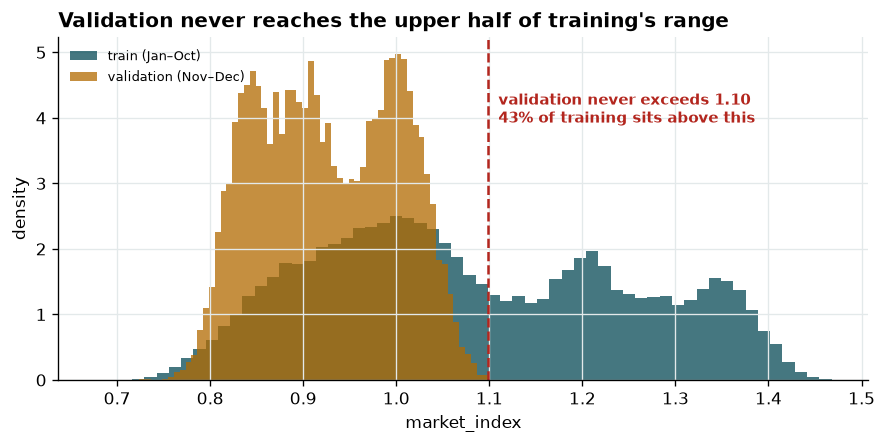

train      mean 1.083   range 0.68–1.47
validation mean 0.927   range 0.72–1.10

share of training above validation's maximum: 42.8%


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))

ax.hist(train.market_index, bins=60, alpha=0.75, color=TEAL, label="train (Jan–Oct)", density=True)
ax.hist(valid.market_index, bins=60, alpha=0.75, color=AMBER, label="validation (Nov–Dec)", density=True)
ax.axvline(valid.market_index.max(), color=RUST, linestyle="--", linewidth=1.5)
ax.annotate(f"validation never exceeds {valid.market_index.max():.2f}\n"
            f"{(train.market_index > valid.market_index.max()).mean():.0%} of training sits above this",
            xy=(valid.market_index.max(), 4.4), xytext=(6, 0), textcoords="offset points",
            fontsize=9, color=RUST, fontweight="bold", va="top")
ax.set_xlabel("market_index")
ax.set_ylabel("density")
ax.set_title("Validation never reaches the upper half of training's range",
             loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

print(f"train      mean {train.market_index.mean():.3f}   range {train.market_index.min():.2f}–{train.market_index.max():.2f}")
print(f"validation mean {valid.market_index.mean():.3f}   range {valid.market_index.min():.2f}–{valid.market_index.max():.2f}")
print(f"\nshare of training above validation's maximum: "
      f"{(train.market_index > valid.market_index.max()).mean():.1%}")

<a id="7"></a>
## 7. Cold start: eight cities appear only at prediction time

Any encoding built on city *names* meets categories it has never seen.

In [9]:
train_cities = set(train.pickup) | set(train.delivery)
valid_cities = set(valid.pickup) | set(valid.delivery)
unseen = sorted(valid_cities - train_cities)

print(f"cities in train      : {len(train_cities)}")
print(f"cities in validation : {len(valid_cities)}")
print(f"unseen at prediction : {len(unseen)} -> {', '.join(unseen)}")

affected = valid[valid.pickup.isin(unseen) | valid.delivery.isin(unseen)]
print(f"\nvalidation loads touching an unseen city: {len(affected):,} ({len(affected) / len(valid):.1%})")
print("\nCoordinates are supplied for these cities, and are fixed per city across the")
print("dataset - so geography-derived features generalise where names cannot.")

cities in train      : 64
cities in validation : 72
unseen at prediction : 8 -> Allentown, Charlotte, Chicago, Jackson, Knoxville, Laredo, Norfolk, San Diego

validation loads touching an unseen city: 1,447 (12.1%)

Coordinates are supplied for these cities, and are fixed per city across the
dataset - so geography-derived features generalise where names cannot.


<a id="8"></a>
## 8. Equipment: the quote does not price it

`quote_signal` is essentially flat across trailer types, but realised rates are not.
The gap is not a uniform shift: the *typical* load of every type lands on its quote, and
what changes is how often a load escapes it.

In [10]:
comparison = pd.DataFrame({
    "mean quote_signal": train.groupby("equipment").quote_signal.mean(),
    "median actual $/mile": train.groupby("equipment").rpm.median(),
})
residual = train.rpm / train.quote_signal
core = residual.between(0.5, 2.0)
comparison["median actual/quote"] = residual[core].groupby(train.equipment[core]).median()
comparison["share paying >20% over quote"] = (residual[core] > 1.2).groupby(train.equipment[core]).mean()
display(comparison.round(4))

,mean quote_signal,median actual $/mile,median actual/quote,share paying >20% over quote
equipment,,,,
Dry Van,2.0474,2.0462,0.9999,0.0994
Flatbed,2.0795,2.2197,1.0068,0.1947
Reefer,2.0840,2.3115,1.0102,0.2627


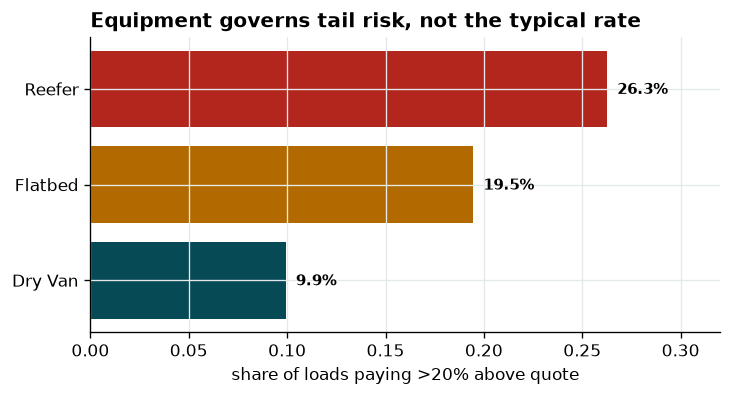

In [11]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
share = (residual[core] > 1.2).groupby(train.equipment[core]).mean().sort_values()
ax.barh(share.index, share.values, color=[TEAL, AMBER, RUST])
for name, value in share.items():
    ax.annotate(f"{value:.1%}", xy=(value, name), xytext=(6, -3),
                textcoords="offset points", fontweight="bold", fontsize=9)
ax.set_xlim(0, 0.32)
ax.set_xlabel("share of loads paying >20% above quote")
ax.set_title("Equipment governs tail risk, not the typical rate", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

A Reefer is **2.6×** as likely as a Dry Van to blow past its quote. That is an argument
for a tail-aware loss or for modelling the deviation separately, not for a simple
per-equipment offset.

The ordering in that table also decides how the column is encoded. By median rate the
types run Dry Van < Flatbed < Reefer. A tree can isolate a category from an integer code,
but only as a contiguous run, so the code's *order* determines which single splits exist:
arbitrary codes of Dry Van=0, Reefer=1, Flatbed=2 put the cheapest type and the dearest on
the same side of one available split, and cost **+1.39 MAE (±0.19)**, the same sign in
all three folds. The model therefore uses one indicator column per type, which assumes no
ordering at all.

<a id="9"></a>
## 9. Temporal structure

Enough autocorrelation to invalidate random cross-validation, and a clear weekly cycle.

,daily median $/mile,daily market level
lag 1,0.844,0.927
lag 2,0.771,0.768
lag 3,0.723,0.640
lag 7,0.789,0.969
lag 14,0.704,0.924
lag 30,0.470,0.541


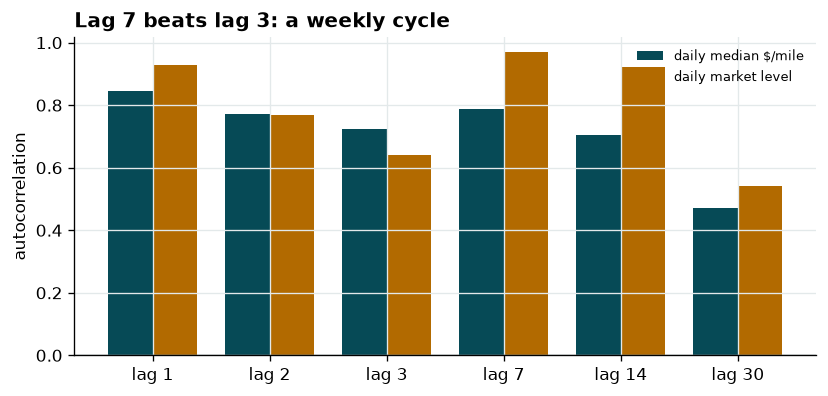

lag-1 autocorrelation of daily $/mile : +0.844
-> a shuffled split trains on Tuesday and tests on Wednesday, which share a market level


In [12]:
daily_rpm = train.groupby("date").rpm.median()
daily_market = train.groupby("date").market_index.mean()

lags = [1, 2, 3, 7, 14, 30]
acf = pd.DataFrame({
    "daily median $/mile": [daily_rpm.autocorr(lag) for lag in lags],
    "daily market level": [daily_market.autocorr(lag) for lag in lags],
}, index=[f"lag {lag}" for lag in lags])
display(acf.round(3))

fig, ax = plt.subplots(figsize=(7, 3.4))
width = 0.38
positions = np.arange(len(lags))
ax.bar(positions - width / 2, acf.iloc[:, 0], width, color=TEAL, label=acf.columns[0])
ax.bar(positions + width / 2, acf.iloc[:, 1], width, color=AMBER, label=acf.columns[1])
ax.set_xticks(positions); ax.set_xticklabels(acf.index)
ax.axhline(0, color=SLATE, linewidth=0.8)
ax.set_ylabel("autocorrelation")
ax.set_title("Lag 7 beats lag 3: a weekly cycle", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f"lag-1 autocorrelation of daily $/mile : {daily_rpm.autocorr(1):+.3f}")
print("-> a shuffled split trains on Tuesday and tests on Wednesday, which share a market level")

<a id="10"></a>
## 10. What this implies

| Finding | Consequence for the model |
|---|---|
| Holdout is forward in time; lag-1 autocorrelation +0.84 | Forward-chaining validation. Random k-fold understates MAE by 37.2% |
| `distance × quote_signal` is within 2% on half the loads | Predict the log ratio against that baseline, not the raw rate |
| Target tail reaches \$14/mile | Log target, so 0.7% of rows do not dominate the loss |
| `market_index` is 97.8% a daily series | Recover the daily level; use it for December, where the column is absent |
| Its range shifts train → validation | Do not lean on the upper half of the learned range |
| 300 loads have no weight recorded | Impute in `fit` from training medians, never in cleaning |
| 8 cities unseen until prediction | The four raw coordinates, never city names and nothing derived from them |
| Equipment drives tail risk, not level | One-hot indicators, so the model assumes no ordering and learns the interaction |
| Lag-7 > lag-3 autocorrelation | Day-of-week as a feature, which recurs and so extrapolates into December |

The last two rows are what the December chart tests. Encoding the date as an ordinal or
a month index produces a flat line, because both fall beyond the training horizon; see
`reports/figures/december_encoding_comparison.png` and
[`src/freight_rate/features/temporal.py`](../src/freight_rate/features/temporal.py).